In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as plt
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [3]:
flights = pd.read_csv("flights.csv")

In [4]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336776 entries, 0 to 336775
Data columns (total 21 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              336776 non-null  int64  
 1   year            336776 non-null  int64  
 2   month           336776 non-null  int64  
 3   day             336776 non-null  int64  
 4   dep_time        328521 non-null  float64
 5   sched_dep_time  336776 non-null  int64  
 6   dep_delay       328521 non-null  float64
 7   arr_time        328063 non-null  float64
 8   sched_arr_time  336776 non-null  int64  
 9   arr_delay       327346 non-null  float64
 10  carrier         336776 non-null  object 
 11  flight          336776 non-null  int64  
 12  tailnum         334264 non-null  object 
 13  origin          336776 non-null  object 
 14  dest            336776 non-null  object 
 15  air_time        327346 non-null  float64
 16  distance        336776 non-null  int64  
 17  hour      

In [5]:
flights

,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,...,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour,name
0,0,2013,1,1,517.0,515,2.0,830.0,819,11.0,...,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01 05:00:00,United Air Lines Inc.
1,1,2013,1,1,533.0,529,4.0,850.0,830,20.0,...,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01 05:00:00,United Air Lines Inc.
2,2,2013,1,1,542.0,540,2.0,923.0,850,33.0,...,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01 05:00:00,American Airlines Inc.
3,3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,...,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01 05:00:00,JetBlue Airways
4,4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,...,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01 06:00:00,Delta Air Lines Inc.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336771,336771,2013,9,30,NaN,1455,NaN,NaN,1634,NaN,...,3393,NaN,JFK,DCA,NaN,213,14,55,2013-09-30 14:00:00,Endeavor Air Inc.
336772,336772,2013,9,30,NaN,2200,NaN,NaN,2312,NaN,...,3525,NaN,LGA,SYR,NaN,198,22,0,2013-09-30 22:00:00,Endeavor Air Inc.
336773,336773,2013,9,30,NaN,1210,NaN,NaN,1330,NaN,...,3461,N535MQ,LGA,BNA,NaN,764,12,10,2013-09-30 12:00:00,Envoy Air
336774,336774,2013,9,30,NaN,1159,NaN,NaN,1344,NaN,...,3572,N511MQ,LGA,CLE,NaN,419,11,59,2013-09-30 11:00:00,Envoy Air


In [6]:
flights1 = flights.copy

In [7]:
# Gives the sum for the null values present in the data set

flights.isnull().sum()

id                   0
year                 0
month                0
day                  0
dep_time          8255
sched_dep_time       0
dep_delay         8255
arr_time          8713
sched_arr_time       0
arr_delay         9430
carrier              0
flight               0
tailnum           2512
origin               0
dest                 0
air_time          9430
distance             0
hour                 0
minute               0
time_hour            0
name                 0
dtype: int64

In [8]:
# Give us the count of different names of airlines in the data set

flights.name.value_counts()

name
United Air Lines Inc.          58665
JetBlue Airways                54635
ExpressJet Airlines Inc.       54173
Delta Air Lines Inc.           48110
American Airlines Inc.         32729
Envoy Air                      26397
US Airways Inc.                20536
Endeavor Air Inc.              18460
Southwest Airlines Co.         12275
Virgin America                  5162
AirTran Airways Corporation     3260
Alaska Airlines Inc.             714
Frontier Airlines Inc.           685
Mesa Airlines Inc.               601
Hawaiian Airlines Inc.           342
SkyWest Airlines Inc.             32
Name: count, dtype: int64

In [9]:
# Gives us the caount of different carries present in the data set

flights.carrier.value_counts()

carrier
UA    58665
B6    54635
EV    54173
DL    48110
AA    32729
MQ    26397
US    20536
9E    18460
WN    12275
VX     5162
FL     3260
AS      714
F9      685
YV      601
HA      342
OO       32
Name: count, dtype: int64

In [10]:
# Gives us the Count of the different of the "origin" in the Data set

flights.origin.value_counts()

origin
EWR    120835
JFK    111279
LGA    104662
Name: count, dtype: int64

/var/folders/78/rjj9ldg9613796n84vly6d640000gn/T/ipykernel_48967/1816093961.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(flights.loc[(flights['origin']=='EWR'),'id'],color='navy',shade=True)


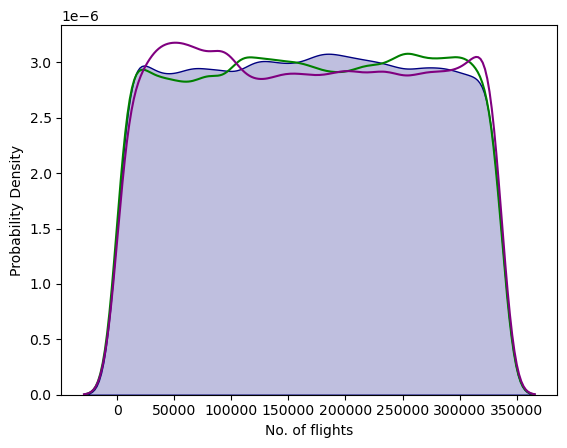

In [11]:
# Makes us the kdle plot for the dataset

sns.kdeplot(flights.loc[(flights['origin']=='EWR'),'id'],color='navy',shade=True)
sns.kdeplot(flights.loc[(flights['origin']=='JFK'),'id'],color='green')
sns.kdeplot(flights.loc[(flights['origin']=='LGA'),'id'],color='purple')
plt.xlabel('No. of flights')
plt.ylabel('Probability Density')
plt.show()


In [12]:
flights.dep_time.mean().round()

np.float64(1349.0)

In [13]:
ls = ["dep_time","sched_dep_time","dep_delay"]

In [14]:
flights[ls]

,dep_time,sched_dep_time,dep_delay
0,517.0,515,2.0
1,533.0,529,4.0
2,542.0,540,2.0
3,544.0,545,-1.0
4,554.0,600,-6.0
...,...,...,...
336771,NaN,1455,NaN
336772,NaN,2200,NaN
336773,NaN,1210,NaN
336774,NaN,1159,NaN


In [15]:
flights.dep_delay.median()

-2.0

In [16]:
# Now we are replacing all nan values in the dep_delay column with the median value

# Correct way: use fillna() on the specific column, not the entire dataframe
flights['dep_delay'] = flights['dep_delay'].fillna(flights['dep_delay'].median())

# Alternative approach using DataFrame.fillna() with a dictionary
# flights = flights.fillna({'dep_delay': flights['dep_delay'].median()})

In [17]:
# Here positive delay shows that flight departed before time
# and the negative delay showes that flight is departed late time
flights[ls]

,dep_time,sched_dep_time,dep_delay
0,517.0,515,2.0
1,533.0,529,4.0
2,542.0,540,2.0
3,544.0,545,-1.0
4,554.0,600,-6.0
...,...,...,...
336771,NaN,1455,-2.0
336772,NaN,2200,-2.0
336773,NaN,1210,-2.0
336774,NaN,1159,-2.0


In [18]:
flights['dep_delay'] = flights['dep_delay'].fillna(flights['dep_delay'].median())


In [19]:
flights["dep_time"] = flights["dep_time"].fillna(flights["sched_dep_time"]+flights["dep_delay"])

In [20]:
ls1=["arr_time","sched_arr_time","arr_delay"]

In [21]:
flights[ls1]

,arr_time,sched_arr_time,arr_delay
0,830.0,819,11.0
1,850.0,830,20.0
2,923.0,850,33.0
3,1004.0,1022,-18.0
4,812.0,837,-25.0
...,...,...,...
336771,NaN,1634,NaN
336772,NaN,2312,NaN
336773,NaN,1330,NaN
336774,NaN,1344,NaN


In [22]:
# Now we are filling the nan values of the arr_delay columns with suitable mean

In [23]:
flights.arr_delay.mean().round()

np.float64(7.0)

In [24]:
flights.arr_delay = flights.arr_delay.fillna(flights.arr_delay.mean().round())

In [25]:
flights.arr_time = flights.arr_delay+flights.sched_arr_time

In [26]:
flights.isnull().sum()

id                   0
year                 0
month                0
day                  0
dep_time             0
sched_dep_time       0
dep_delay            0
arr_time             0
sched_arr_time       0
arr_delay            0
carrier              0
flight               0
tailnum           2512
origin               0
dest                 0
air_time          9430
distance             0
hour                 0
minute               0
time_hour            0
name                 0
dtype: int64

In [27]:
flights.air_time.median()

129.0

In [28]:
# Now we are replacing the null values of the "air_time with the median of the "air_time""

flights.air_time = flights.air_time.fillna(129)

In [29]:
# Now lets calculate no of flights in the months

In [30]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336776 entries, 0 to 336775
Data columns (total 21 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              336776 non-null  int64  
 1   year            336776 non-null  int64  
 2   month           336776 non-null  int64  
 3   day             336776 non-null  int64  
 4   dep_time        336776 non-null  float64
 5   sched_dep_time  336776 non-null  int64  
 6   dep_delay       336776 non-null  float64
 7   arr_time        336776 non-null  float64
 8   sched_arr_time  336776 non-null  int64  
 9   arr_delay       336776 non-null  float64
 10  carrier         336776 non-null  object 
 11  flight          336776 non-null  int64  
 12  tailnum         334264 non-null  object 
 13  origin          336776 non-null  object 
 14  dest            336776 non-null  object 
 15  air_time        336776 non-null  float64
 16  distance        336776 non-null  int64  
 17  hour      

In [31]:
flights.month.value_counts()

month
7     29425
8     29327
10    28889
3     28834
5     28796
4     28330
6     28243
12    28135
9     27574
11    27268
1     27004
2     24951
Name: count, dtype: int64

In [32]:
# Now lets make the histograph based on the months and the flights

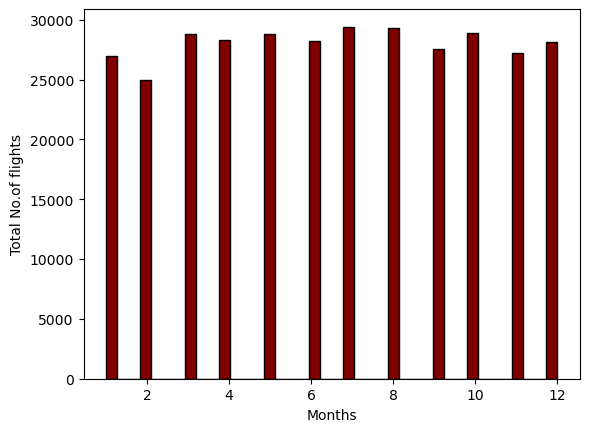

In [37]:
data=flights.month
plt.hist(data,bins=40,color='maroon',edgecolor='black',rwidth=1.5)
plt.xlabel('Months')
plt.ylabel('Total No.of flights')
plt.show()

In [ ]:
# Makin the histograph for the data set

data = flights.month
plt.hist(data,bins = 40,color = "maroon",edgecolor = "black",rwidth = 4)
plt.xlabel("Months")
plt.ylabel("Total No. of Flights")
plt.show()

In [ ]:
# Now we are working the columns name ["'air_time','distance','origin'"]

In [ ]:
lr  = ['air_time','distance','origin']

In [ ]:
flights[lr]

In [ ]:
# Now we are making the kdeplot

x = flights.distance
y = flights.air_time
sns.kdeplot(x,fill = True)


In [ ]:
# Now we works on the "tailnum"

flights.tailnum

In [ ]:
flights.info()

In [ ]:
# This vill gives us that how many flights are going in which city or desintation of the flights

flights.dest.value_counts()

In [ ]:
lr1= ['origin','dest']

In [ ]:
flights[lr1]

In [ ]:
flights.origin.value_counts()

In [ ]:
flights[flights["origin"]=="EWR"]["dest"].value_counts()

In [ ]:
flights[flights["origin"]=="JFK"]['dest'].value_counts()

In [ ]:
flights[flights["origin"]=="LGA"]["dest"].value_counts()

In [ ]:
EWR=flights[flights['origin']=='EWR']['dest'].value_counts()
LGA=flights[flights['origin']=='LGA']['dest'].value_counts()
JFK=flights[flights['origin']=='JFK']['dest'].value_counts()
df1=pd.DataFrame([EWR,LGA,JFK])
df1.index=['EWR','LGA','JFK']
df1.plot(kind='bar',stacked=True,figsize=(10,5))

In [ ]:
flights.name.value_counts()

<Axes: >

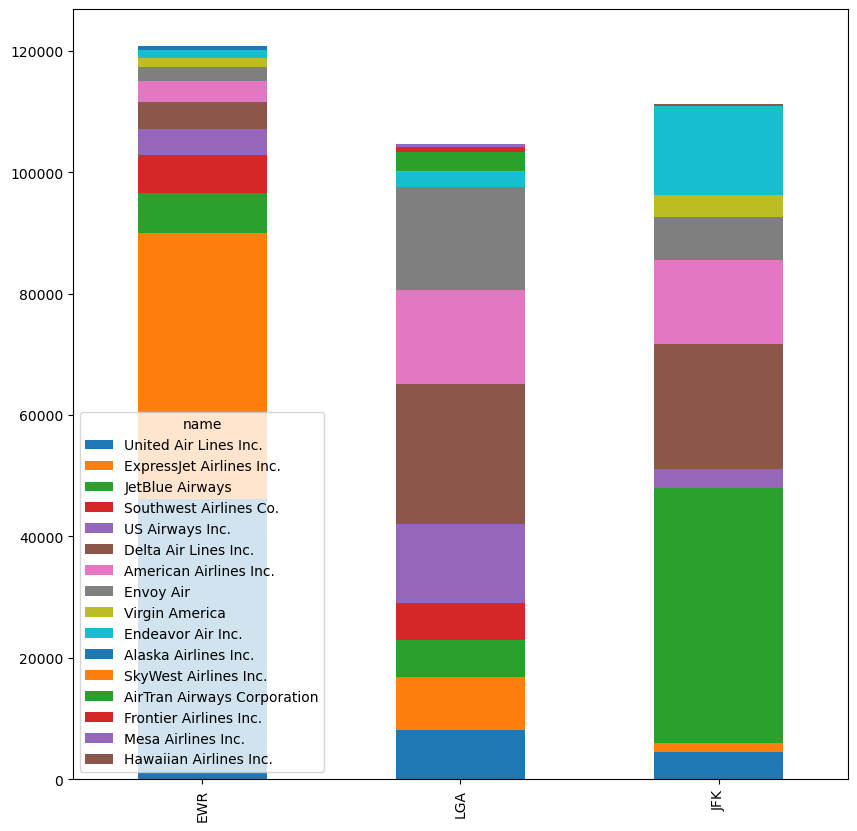

In [34]:
EWR=flights[flights['origin']=='EWR']['name'].value_counts()
LGA=flights[flights['origin']=='LGA']['name'].value_counts()
JFK=flights[flights['origin']=='JFK']['name'].value_counts()
df1=pd.DataFrame([EWR,LGA,JFK])
df1.index=['EWR','LGA','JFK']
df1.plot(kind='bar',stacked=True,figsize=(10,10))

<Axes: >

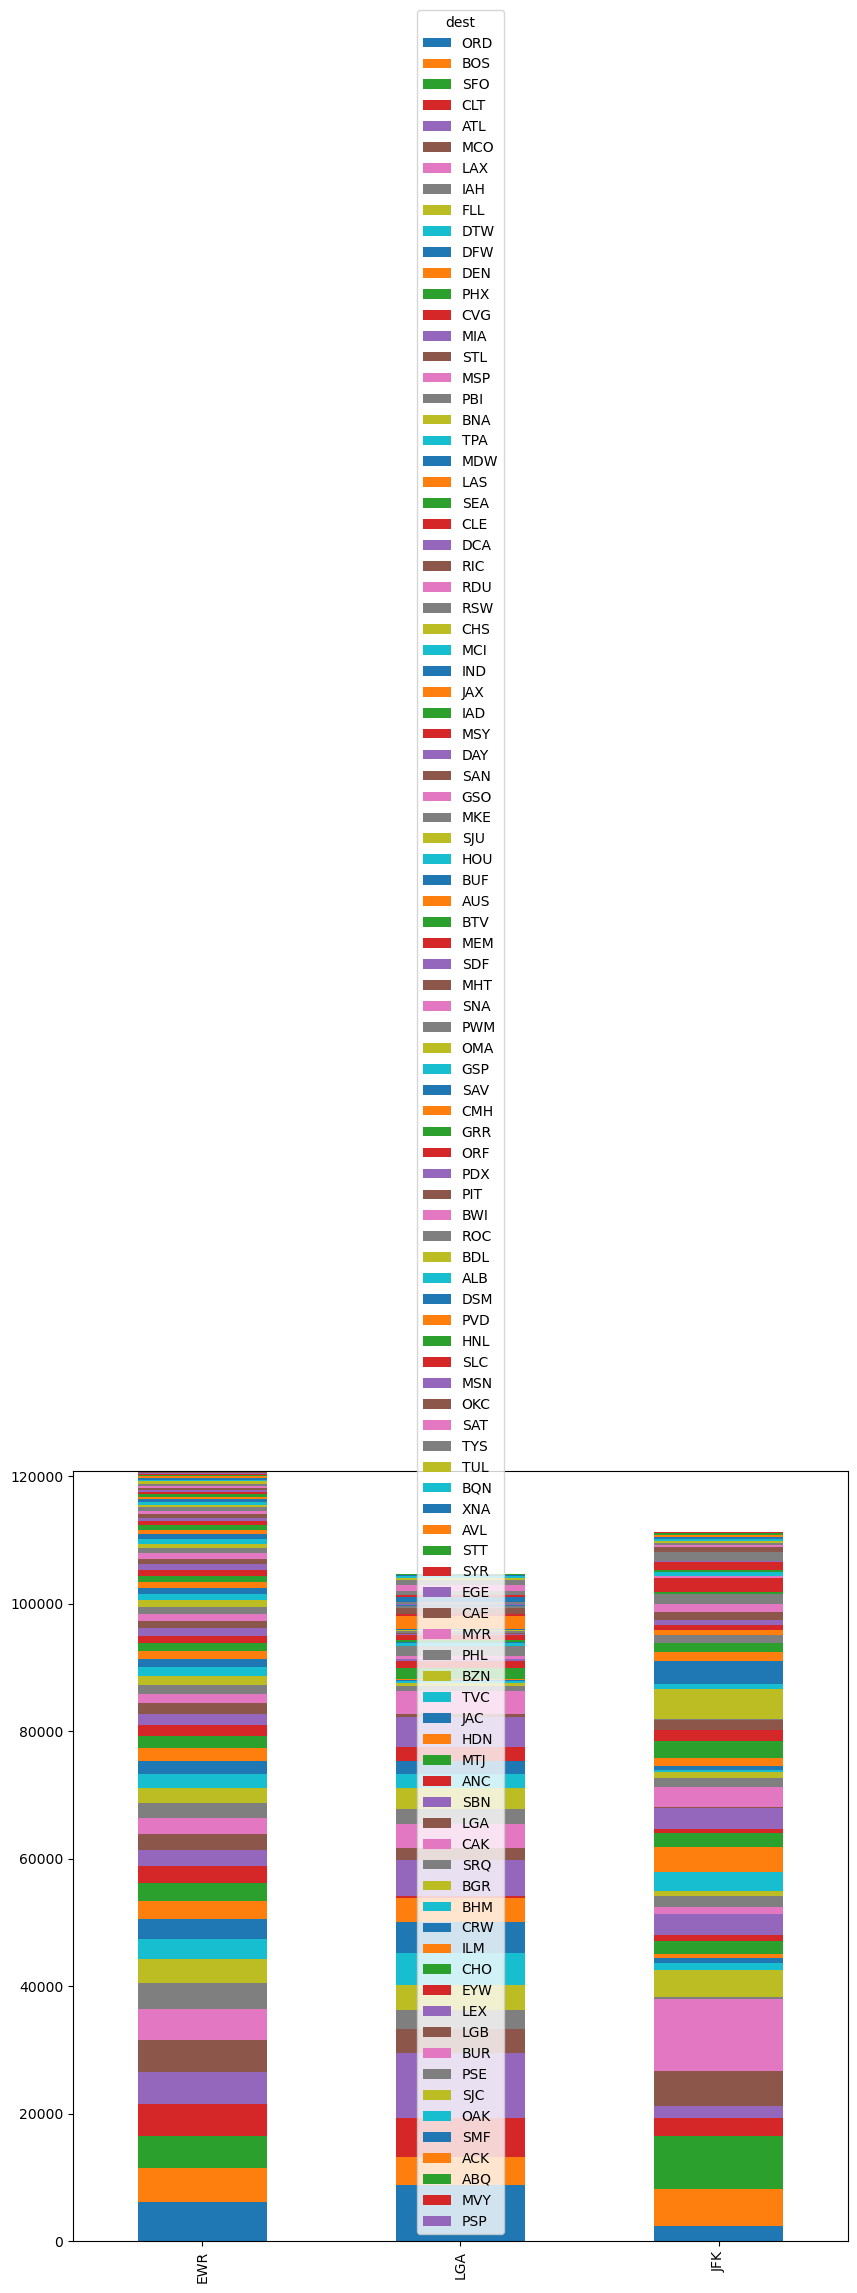

In [35]:
EWR = flights[flights["origin"]=="EWR"]["dest"].value_counts()
LGA = flights[flights["origin"]=="LGA"]["dest"].value_counts()
JFK = flights[flights["origin"]=="JFK"]["dest"].value_counts()

df2=pd.DataFrame([EWR,LGA,JFK])
df2.index = ["EWR",'LGA','JFK']
df2.plot(kind = "bar",stacked =True,figsize=(10,10))


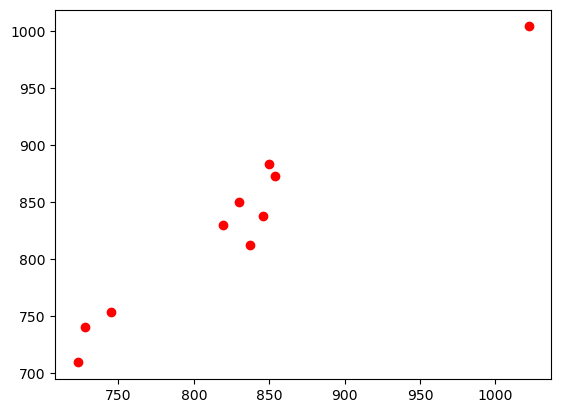

In [39]:
x=flights.sched_arr_time.head(10)
y=flights.arr_time.head(10)
plt.scatter(x,y,color='red')
plt.show()


In [41]:
flights.carrier.value_counts()

carrier
UA    58665
B6    54635
EV    54173
DL    48110
AA    32729
MQ    26397
US    20536
9E    18460
WN    12275
VX     5162
FL     3260
AS      714
F9      685
YV      601
HA      342
OO       32
Name: count, dtype: int64

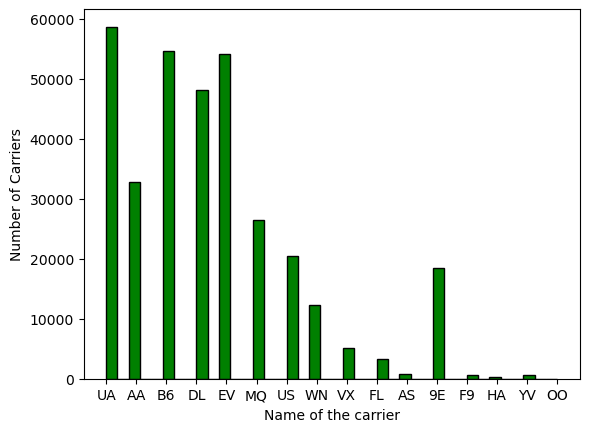

In [43]:
data = flights.carrier
plt.hist(data,bins = 40,color = "green",edgecolor = "black",rwidth = 1.5)
plt.xlabel("Name of the carrier")
plt.ylabel("Number of Carriers")
plt.show()

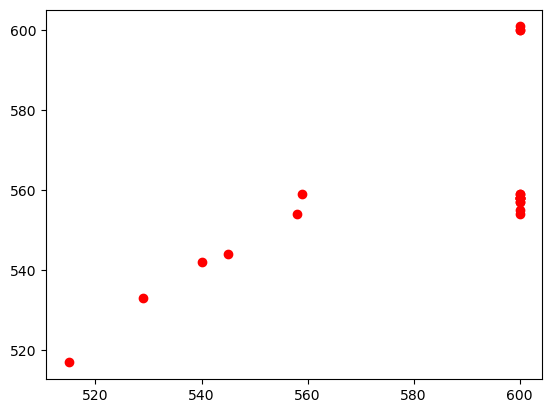

In [44]:
x=flights.sched_dep_time.head(20)
y=flights.dep_time.head(20)
plt.scatter(x,y,color='red')
plt.show()
